# Supervised Models

Until now no model ever saw a label while it was training. CUSUM, the Z-scores, Isolation Forest and the One-Class SVM all decided alone what looks normal, and the labels only came at the end, to give them a score. Here we do the opposite. Random Forest and XGBoost see the labels of DS1 while they train. Both are tuned with a grid search, so the comparison with the older methods is fair. We reuse the 35 features saved in notebook 03, so nothing is computed again from the raw signal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



from m1_defect_anomaly_2026.evaluation import evaluate_scores, select_threshold, build_table, save_table
from m1_defect_anomaly_2026.unsupervised import feature_columns
from m1_defect_anomaly_2026.supervised import (fit_random_forest, fit_xgboost, predict_scores,
                                                oof_scores, shap_values, shap_importance)

FEATURES_DIR = Path("../results/features_unsupervised")
RESULTS_DIR = Path("../results/supervised_ml")
FIG_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

/workspaces/2026-m1-internship-defect-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 - The features from notebook 03

Same split, same 35 columns. We only add groups, which says which patient each beat comes from: the grid search needs it to keep a patient inside one fold.

In [2]:
train = pd.read_parquet(FEATURES_DIR / "features_ds1.parquet")
test = pd.read_parquet(FEATURES_DIR / "features_ds2.parquet")

cols = feature_columns(train)
y_train = train["y"].to_numpy()
y_test = test["y"].to_numpy()
groups = train["record"].to_numpy()

print("DS1 train:", train.shape)
print("DS2 test :", test.shape)
print("number of features:", len(cols))

DS1 train: (51003, 38)
DS2 test : (49692, 38)
number of features: 35


## 2 - Random Forest

The grid search tries 16 combinations, each one on 5 folds, so the model is fitted 80 times. It takes a few minutes.

In [ ]:
import time

start = time.time()

In [4]:
rf = fit_random_forest(train[cols], y_train, groups)

print("best parameters:", rf.best_params_)
print("best F1 in cross-validation:", round(rf.best_score_, 3))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END class_weight=None, max_depth=None, min_samples_leaf=1; total time=  51.8s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=1; total time=  55.9s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=1; total time=  54.1s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=1; total time=  56.7s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=1; total time=  49.9s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=4; total time=  53.4s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=4; total time=  51.2s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=4; total time=  52.5s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=4; total time=  54.4s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=4; total time=  47.9s
[CV] END class_weight=None, max_depth=12, min_samples_leaf=1; total time=  39.9s
[CV] END class_weight=None, m

The search kept class_weight='balanced', max_depth=12 and min_samples_leaf=1, and got
F1 = 0.74 in cross-validation on DS1. Limiting the depth to 12 did not hurt the score,
so the deeper trees were only learning noise. 'balanced' winning was expected: only 11%
of the beats are anomalies, so without it the model can ignore them and still look good.

We choose the threshold on DS1 and we measure on DS2, like in notebooks 02 and 03. But there is one difference here: the model was trained on DS1, so it already knows those beats and it is too sure about them. A threshold chosen on those scores would be too optimistic. oof_scores gives each beat a score computed by the folds that did not train on it, which is closer to what the model does on a beat it has never seen.

In [5]:
rf_train_scores = oof_scores(rf, train[cols], y_train, groups)
rf_test_scores = predict_scores(rf, test[cols])

rf_threshold, rf_f1_train = select_threshold(y_train, rf_train_scores)
rf_result = evaluate_scores(y_test, rf_test_scores, rf_threshold, "Random Forest")

print("F1 on DS1:", round(rf_f1_train, 3))
print("F1 on DS2:", round(rf_result["f1"], 3))
print("ROC-AUC on DS2:", round(rf_result["roc_auc"], 3))

F1 on DS1: 0.777
F1 on DS2: 0.721
ROC-AUC on DS2: 0.948


F1 goes from 0.777 on DS1 to 0.721 on DS2, so the model loses only a little on
patients it has never seen. ROC-AUC on DS2 is 0.948, against 0.836 for Isolation
Forest, and F1 is 0.721 against 0.427. The labels clearly help.

## 3 - XGBoost

Same protocol. The grid also tries scale_pos_weight, so the search decides by itself if giving more weight to the anomalies helps or not.

In [6]:
xgb = fit_xgboost(train[cols], y_train, groups)

print("best parameters:", xgb.best_params_)
print("best F1 in cross-validation:", round(xgb.best_score_, 3))

best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'scale_pos_weight': np.float64(8.89580908032596)}
best F1 in cross-validation: 0.725


The search kept scale_pos_weight, so like the forest with 'balanced', XGBoost also
needed help with the imbalance. It took 3m5s for 80 fits, against 13m for 40 fits
of the forest, so it is much faster to tune.

In [7]:
xgb_train_scores = oof_scores(xgb, train[cols], y_train, groups)
xgb_test_scores = predict_scores(xgb, test[cols])

xgb_threshold, xgb_f1_train = select_threshold(y_train, xgb_train_scores)
xgb_result = evaluate_scores(y_test, xgb_test_scores, xgb_threshold, "XGBoost")

print("F1 on DS1:", round(xgb_f1_train, 3))
print("F1 on DS2:", round(xgb_result["f1"], 3))
print("ROC-AUC on DS2:", round(xgb_result["roc_auc"], 3))

F1 on DS1: 0.728
F1 on DS2: 0.681
ROC-AUC on DS2: 0.94


XGBoost is behind the Random Forest everywhere: F1 0.681 against 0.721 on DS2,
ROC-AUC 0.940 against 0.948. Its drop from DS1 to DS2 is about the same size
(0.728 to 0.681), so both models lose a similar amount on new patients. The two
models agree more with each other than with the unsupervised ones, which suggests
the limit now comes from the features, not from the choice of model.

## 4 - Which features does the model use?

We explain the better of the two models, on beats of DS2, so the explanation talks about the same beats as the score.

In [8]:
if rf_result["f1"] >= xgb_result["f1"]:
    best_name, best_model = "Random Forest", rf.best_estimator_
    best_scores, best_threshold = rf_test_scores, rf_threshold
else:
    best_name, best_model = "XGBoost", xgb.best_estimator_
    best_scores, best_threshold = xgb_test_scores, xgb_threshold

print("we explain:", best_name)

X_shap, values = shap_values(best_model, test[cols])
importance = shap_importance(values, cols)
importance.head(15)

we explain: Random Forest


heart_rate           0.080322
rr_deviation         0.080137
pre_rr               0.055834
rr_ratio             0.043726
spectral_centroid    0.039105
spectral_entropy     0.025028
lf_ratio             0.019588
local_rmssd          0.017046
cD4_energy           0.015814
dominant_freq        0.014903
post_rr              0.013590
mad                  0.013137
std                  0.013004
cA4_energy           0.012586
cA4_std              0.012327
dtype: float64

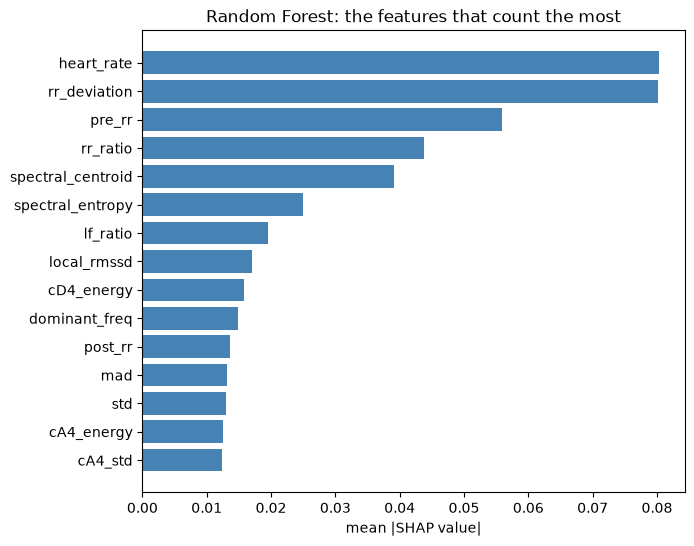

In [9]:
top = importance.head(15).iloc[::-1]

plt.figure(figsize=(7, 6))
plt.barh(top.index, top.values, color="steelblue")
plt.xlabel("mean |SHAP value|")
plt.title(f"{best_name}: the features that count the most")
plt.savefig(FIG_DIR / "shap_importance.png", dpi=150)

The four features at the top heart_rate, rr_deviation, pre_rr, rr_ratio all say
the same kind of thing: when does this beat arrive compared to the ones around it.
So the model looks at rhythm first, and at the shape of the beat only after. pre_rr
was already the feature that separated the S beats by hand in notebook 03, and the
model found it alone. The bars go down slowly, from 0.080 to 0.012, and no feature stands far above the others. So there is no single rule like "if pre_rr is small then it is an anomaly". The model adds many small clues together.


The plot above is an average over 1000 beats. A cardiologist asks about one beat, not about an average. We take one real anomaly that the model flagged, and we look at what pushed it up (red) or down (blue).

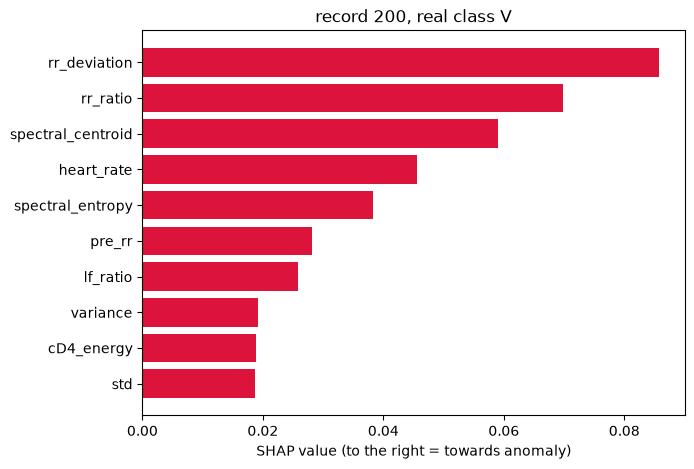

In [10]:
flagged = pd.Series(best_scores >= best_threshold, index=test.index)
sample = test.loc[X_shap.index]
caught = sample[(sample["y"] == 1) & flagged.loc[X_shap.index]]

position = sample.index.get_loc(caught.index[0])
beat = sample.iloc[position]

contributions = pd.Series(values[position], index=cols)
contributions = contributions.reindex(contributions.abs().sort_values().index).tail(10)

plt.figure(figsize=(7, 5))
colors = ["crimson" if v > 0 else "steelblue" for v in contributions]
plt.barh(contributions.index, contributions.values, color=colors)
plt.xlabel("SHAP value (to the right = towards anomaly)")
plt.title(f"record {beat['record']}, real class {beat['label']}")
plt.savefig(FIG_DIR / "shap_one_beat.png", dpi=150)

Every bar is red, so every feature pushes this beat towards "anomaly" and none of them
says "normal". Nothing contradicts, so the model flags it without hesitating.

The two strongest are rr_deviation and rr_ratio: this beat does not arrive when it should
compared to the beats around it. Right after comes spectral_centroid, which says the shape of the beat is different too, and the small ones at the bottom (variance, cD4_energy, std) also talk about the shape. So the model sees two separate signs, the timing and the shape, and they agree with each other.

The beat is really a V. A V beat starts in the ventricle instead of the normal place, so it comes too early and it is wider than a normal beat. That is exactly the two things the model used, so it is right for the right reasons.

## 5 - Which classes do they catch?

Same table as the end of notebook 03, with the two new models.

In [11]:
test["rf_flag"] = (rf_test_scores >= rf_threshold).astype(int)
test["xgb_flag"] = (xgb_test_scores >= xgb_threshold).astype(int)

anomalies = test[test.y == 1]
per_class = anomalies.groupby("label").agg(n_beats=("y", "size"),
                                            caught_by_rf=("rf_flag", "mean"),
                                            caught_by_xgb=("xgb_flag", "mean"))
print(per_class.round(3).to_string())

       n_beats  caught_by_rf  caught_by_xgb
label                                      
F          388         0.281          0.351
Q            7         0.286          0.571
S         1837         0.161          0.275
V         3220         0.946          0.946


The models are very good on V (0.946 both) and very bad on S: the Random Forest catches
only 16% of them, XGBoost 27%. F is not much better, around 30%. Q has only 7 beats, so
that number means nothing.

So the models did not really learn to find anomalies, they learned to find V beats. And
S is the class where the beat comes early but keeps a normal shape, so only the rhythm
features can see it, while V is visible both by rhythm and by shape. That matches the
SHAP plot: the model has two kinds of clues for V and only one for S.

XGBoost is worse in F1 overall but better on S and F, so the two models do not fail in
the same way.

## 6 - All the methods together

Same test set, same metrics, same way of choosing the threshold, from notebook 02 until now.

In [12]:
previous = pd.read_csv(FEATURES_DIR / "comparison_table.csv")
results = previous.to_dict("records") + [rf_result, xgb_result]

table = build_table(results)
table[["method", "precision", "recall", "f1", "roc_auc"]]

,method,precision,recall,f1,roc_auc
0,Random Forest,0.836848,0.633162,0.720894,0.947969
1,XGBoost,0.686129,0.676816,0.681440,0.939715
2,Isolation Forest,0.342546,0.566031,0.426803,0.836036
3,Spectral features,0.297327,0.501834,0.373413,0.773129
4,CUSUM (k=0.5),0.410245,0.334923,0.368777,0.679941
5,Z-score (10s window),0.651847,0.174798,0.275673,0.614689
6,One-Class SVM,0.200185,0.437454,0.274675,0.687392
7,Random baseline,0.109734,0.995598,0.197680,0.499588
8,Z-score (1s window),0.109636,0.996515,0.197538,0.274422


The two supervised models are clearly ahead: F1 0.72 and 0.68 against 0.43 for the best
unsupervised one, and ROC-AUC 0.95 against 0.84. So the labels really bring something,
they are not just a small bonus.

What changes is precision, not recall. Isolation Forest already found a bit more than half of the anomalies (0.57), and the Random Forest finds about the same (0.63). But when Isolation Forest says "anomaly" it is right only 1 time out of 3, while the Random Forest is right 5 times out of 6. So the labels did not teach the model to see more anomalies, they taught it to stop flagging normal beats.

The last two lines show why we look at F1 and not at recall: the random baseline and the
1-second Z-score catch 99% of the anomalies, simply because they flag almost everything.

In [13]:
save_table(table, csv_path=str(RESULTS_DIR / "comparison_table.csv"),
           md_path=str(RESULTS_DIR / "comparison_table.md"))

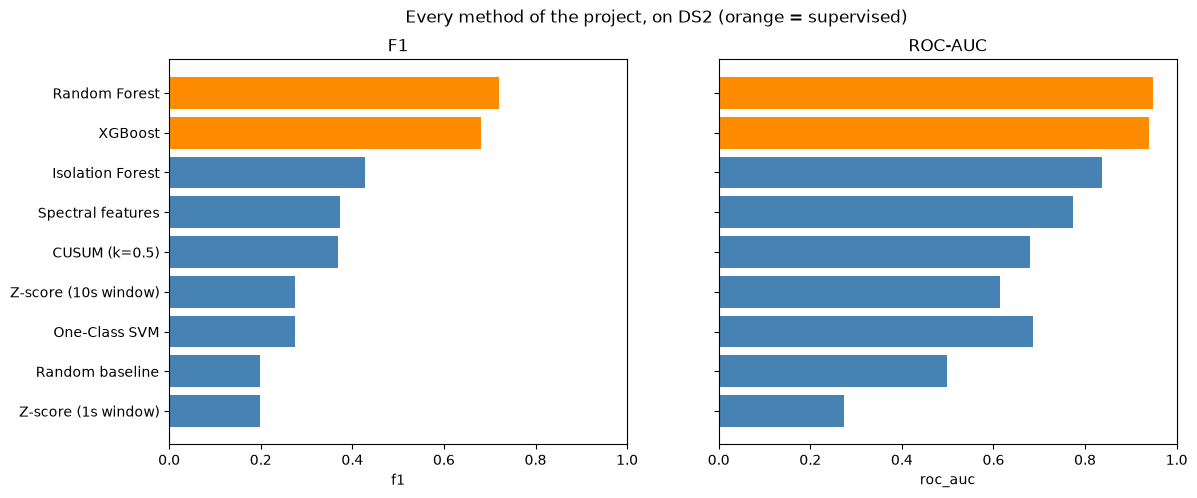

In [14]:
scores = table.set_index("method")[["f1", "roc_auc"]].sort_values("f1")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metric in zip(axes, ["f1", "roc_auc"]):
    colors = ["darkorange" if m in ("Random Forest", "XGBoost") else "steelblue"
              for m in scores.index]
    ax.barh(scores.index, scores[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_xlim(0, 1)

axes[0].set_title("F1")
axes[1].set_title("ROC-AUC")
fig.suptitle("Every method of the project, on DS2 (orange = supervised)")
plt.savefig(FIG_DIR / "all_methods.png", dpi=150)

The two orange bars are on top in both panels, so the supervised models win whatever
metric we look at. The jump is big: from 0.43 to 0.72 in F1, and from 0.84 to 0.95 in
ROC-AUC.

The left and the right panel do not tell the same story. In F1 the methods are spread
out, in ROC-AUC most of them sit between 0.6 and 0.85, so they are not that far from
each other. This is because ROC-AUC only asks if the anomalies get a higher score than
the normal beats, while F1 also asks to pick the right threshold, which is much harder
when only 11% of the beats are anomalies.